In [1]:
import os, json
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
import torch, torchvision, time, copy, random, timm
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import numpy as np
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, f1_score, recall_score
import seaborn as sn
import pandas as pd
from torch.cuda.amp import autocast, GradScaler
import time
import copy
import torch
import gc

RUN_SEEDS = {
    "baseline": 2,
    "aug_exp_01": 13,
    "aug_exp_02": 42,
}
ACTIVE_RUN_SEED = RUN_SEEDS["aug_exp_02"]

Num_class = 5

# Weights
CLASS_WEIGHT_MODE = "manual"
MANUAL_WEIGHTS    = {
    "Cavity": 2.5,
    "Fillings": 1.5,
    "Impacted Tooth": 1.5,
    "Implant": 1.0,
    "Normal": 1.0,
}

# Runs
RUN_NAME = f"weighted-ce-{CLASS_WEIGHT_MODE}"   # <-- the ONLY thing to rename per experiment
NUM_EPOCHS = 15

# Saving results
RESULTS_ROOT = "new-results/"
MASTER_LOG   = "new-results/experiments_log.csv"

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

e:\Rodrigo Neves\dental-radiography-classification\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def seed_everything(seed):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    try:
        torch.use_deterministic_algorithms(True)
    except Exception:
        pass


def seed_worker(worker_id):
    worker_seed = ACTIVE_RUN_SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)
    torch.manual_seed(worker_seed)


seed_everything(ACTIVE_RUN_SEED)

In [3]:
@torch.no_grad()
def _predict(model, loader):
    """Run the (already-trained, best-weights) model over the eval set once."""
    model.eval()
    y_true, y_pred = [], []
    for inputs, labels in loader:
        outputs = model(inputs.to(device))
        preds = torch.max(outputs, 1)[1]
        y_pred.extend(preds.cpu().numpy().tolist())
        y_true.extend(labels.cpu().numpy().tolist())
    return np.array(y_true), np.array(y_pred)


def _gap_metrics(history):
    """Turn the train/val curves into the numbers we care about."""
    tr_acc, va_acc = np.array(history["train_acc"]),  np.array(history["valid_acc"])
    tr_loss, va_loss = np.array(history["train_loss"]), np.array(history["valid_loss"])
    best = int(np.argmax(va_acc))                       # the epoch we'd "keep" (max val acc)
    return {
        "best_val_epoch": best,
        "best_val_acc":   float(va_acc[best]),
        # gap at the kept epoch — POSITIVE means train is ahead of val (overfitting).
        # This is the number you want to shrink.
        "gap_acc_best":   float(tr_acc[best] - va_acc[best]),
        "gap_loss_best":  float(va_loss[best] - tr_loss[best]),
        # gap at the final epoch — sanity check that it didn't blow up late
        "final_gap_acc":  float(tr_acc[-1] - va_acc[-1]),
        "final_gap_loss": float(va_loss[-1] - tr_loss[-1]),
    }


def _column_order(class_names):
    """Canonical CSV schema + column order (single source of truth).
    The test_* block sits right after the validation columns (recall_*) and
    before aug_desc/notes, in the same order as the validation block."""
    val_recall  = [f"recall_{c.replace(' ', '_')}"      for c in class_names]
    test_recall = [f"test_recall_{c.replace(' ', '_')}" for c in class_names]
    return (
        ["run_name", "seed", "epoch_tag", "num_epochs",
         "best_val_epoch", "best_val_acc", "gap_acc_best", "gap_loss_best",
         "final_gap_acc", "final_gap_loss",
         "val_macro_f1", "val_weighted_f1"]
        + val_recall
        + ["test_acc", "test_macro_f1", "test_weighted_f1"]
        + test_recall
        + ["aug_desc", "notes"]
    )


def log_experiment(run_name, history, model, valid_loader, test_y_true, test_y_pred,
                    class_names, seed, num_epochs, aug_desc, notes=""):
    epoch_tag = f"{num_epochs}-epoch"
    run_dir = os.path.join(RESULTS_ROOT, epoch_tag, run_name, f"seed{seed}")
    os.makedirs(run_dir, exist_ok=True)

    # 1) loss/accuracy curves -> PNG (y-lim matches your old graphs for visual parity)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history["train_loss"], label="Treino", marker="o")
    ax1.plot(history["valid_loss"], label="Validação", marker="o")
    ax1.set_title("Cross-Entropy Loss"); ax1.set_xlabel("Época"); ax1.set_ylabel("Loss")
    ax1.set_ylim(0, 0.8); ax1.legend(); ax1.grid(True, linestyle="--", alpha=0.7)
    ax2.plot(history["train_acc"], label="Treino", marker="o")
    ax2.plot(history["valid_acc"], label="Validação", marker="o")
    ax2.set_title("Acurácia"); ax2.set_xlabel("Época"); ax2.set_ylabel("Acurácia")
    ax2.legend(); ax2.grid(True, linestyle="--", alpha=0.7)
    fig.tight_layout()
    fig.savefig(os.path.join(run_dir, "loss-accuracy-graph.png"), dpi=150, bbox_inches="tight")
    plt.close(fig)

    # 2) VALIDATION predictions -> confusion matrix PNG + per-class recall
    y_true, y_pred = _predict(model, valid_loader)
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
    fig2 = plt.figure(figsize=(10, 8))
    sn.heatmap(pd.DataFrame(cm, index=class_names, columns=class_names), annot=True, fmt="d")
    plt.ylabel("Labels"); plt.xlabel("Predictions"); plt.title(f"Confusion Matrix - {run_name}")
    fig2.savefig(os.path.join(run_dir, "confusion-matrix.png"), bbox_inches="tight")
    plt.close(fig2)
    per_class_recall = recall_score(y_true, y_pred, average=None,
                                    labels=list(range(len(class_names))), zero_division=0)

    # 2b) TEST metrics — computed from predictions already produced ONCE in the test
    #     cell (no extra forward pass over the test set here).
    test_y_true = np.asarray(test_y_true)
    test_y_pred = np.asarray(test_y_pred)
    test_per_class_recall = recall_score(test_y_true, test_y_pred, average=None,
                                         labels=list(range(len(class_names))), zero_division=0)

    # 3) assemble ONE row of metrics
    m = _gap_metrics(history)
    row = {
        "run_name": run_name, "seed": seed, "epoch_tag": epoch_tag, "num_epochs": num_epochs,
        **m,
        "val_macro_f1":    float(f1_score(y_true, y_pred, average="macro")),
        "val_weighted_f1": float(f1_score(y_true, y_pred, average="weighted")),
        **{f"recall_{c.replace(' ', '_')}": float(r)
            for c, r in zip(class_names, per_class_recall)},
        "test_acc":         float(np.mean(test_y_true == test_y_pred)),
        "test_macro_f1":    float(f1_score(test_y_true, test_y_pred, average="macro")),
        "test_weighted_f1": float(f1_score(test_y_true, test_y_pred, average="weighted")),
        **{f"test_recall_{c.replace(' ', '_')}": float(r)
            for c, r in zip(class_names, test_per_class_recall)},
        "aug_desc": aug_desc, "notes": notes,
    }

    # 4) raw history -> JSON (so we can re-plot / overlay curves later)
    with open(os.path.join(run_dir, "history.json"), "w") as f:
        json.dump({"history": history, "metrics": row}, f, indent=2)

    # 5) append the row to the master table.
    #    Schema-aware: if the existing log still has the old columns (no test_*),
    #    migrate it ONCE — old rows keep their values and the new test_* cells
    #    become empty (NaN -> blank on write). Then append this run's row.
    cols = _column_order(class_names)
    df_row = pd.DataFrame([row]).reindex(columns=cols)
    if os.path.exists(MASTER_LOG):
        prev = pd.read_csv(MASTER_LOG)
        if list(prev.columns) != cols:
            prev.reindex(columns=cols).to_csv(MASTER_LOG, index=False)
        df_row.to_csv(MASTER_LOG, mode="a", header=False, index=False)
    else:
        os.makedirs(os.path.dirname(MASTER_LOG), exist_ok=True)
        df_row.to_csv(MASTER_LOG, index=False)

    # 6) print a human summary
    print(f"\n===== {run_name} (seed {seed}) =====")
    print(f"best val acc   : {m['best_val_acc']:.4f} @ epoch {m['best_val_epoch']}")
    print(f"gap acc / loss : {m['gap_acc_best']:.4f} / {m['gap_loss_best']:.4f}   (smaller = curves closer)")
    print(f"val  macro-F1  : {row['val_macro_f1']:.4f}")
    print(f"test acc       : {row['test_acc']:.4f}")
    print(f"test macro-F1  : {row['test_macro_f1']:.4f}")
    for c, r in zip(class_names, per_class_recall):
        print(f"   recall {c:<16} {r:.3f}")
    print(f"saved -> {run_dir}")
    return row


def show_log(sort_by="gap_acc_best"):
    """Pretty view of all experiments so far, sorted by whatever you care about."""
    df = pd.read_csv(MASTER_LOG)
    cols = (["run_name", "seed", "best_val_acc", "gap_acc_best", "gap_loss_best", "val_macro_f1"]
            + [c for c in df.columns if c.startswith("recall_")])
    return df[cols].sort_values(sort_by)


def reset_log():
    """Call this ONLY if you change the set of metrics (columns); then re-run experiments."""
    if os.path.exists(MASTER_LOG):
        os.remove(MASTER_LOG)
    print("master log cleared")


In [4]:
import sys
print(sys.executable)
# !pwd
# %cd /content/drive/MyDrive/TCC/db-dental-radiography-classification/

e:\Rodrigo Neves\dental-radiography-classification\.venv\Scripts\python.exe


In [5]:
# Uncomment this if you are working with the zipped dataset
# with zipfile.ZipFile('/kaggle/input/dental-radiography-more-balanced-subset/Dental_Data.zip', 'r') as zip_ref:
#         # Extract all contents
#         zip_ref.extractall('./')

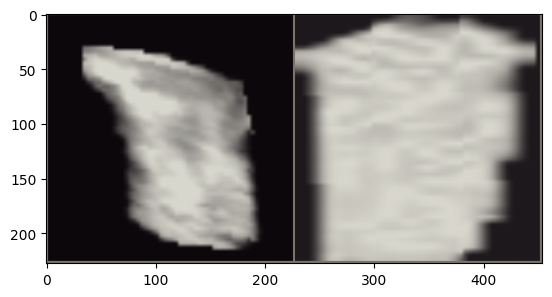

In [6]:
# Data augmentation and normalization for training
# Just normalization for validation
seed_everything(ACTIVE_RUN_SEED)

EPOCH_SEED_STRIDE = 1000003


class SeededTransformDataset(torch.utils.data.Dataset):
    def __init__(self, base_dataset, seed):
        self.base_dataset = base_dataset
        self.seed = int(seed)
        self.epoch = 0
        self.classes = getattr(base_dataset, "classes", None)
        self.class_to_idx = getattr(base_dataset, "class_to_idx", None)

    def set_epoch(self, epoch):
        self.epoch = int(epoch)

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, index):
        combined_seed = self.seed + (self.epoch * EPOCH_SEED_STRIDE) + index
        random.seed(combined_seed)
        np.random.seed(combined_seed % (2**32 - 1))
        torch.manual_seed(combined_seed)
        torch.cuda.manual_seed(combined_seed)
        return self.base_dataset[index]


train_transforms = transforms.Compose([
    transforms.RandomRotation(10,),
    transforms.RandomPerspective(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomAutocontrast(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 0.5)),
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.507, 0.487, 0.441], std=[0.267, 0.256, 0.276])
])

eval_transforms = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.507, 0.487, 0.441], std=[0.267, 0.256, 0.276])
])

data_dir = './original-dataset'
base_datasets = {
    'train': datasets.ImageFolder(os.path.join(data_dir, 'train'), train_transforms),
    'valid': datasets.ImageFolder(os.path.join(data_dir, 'valid'), eval_transforms),
    'test': datasets.ImageFolder(os.path.join(data_dir, 'test'), eval_transforms),
}

image_datasets = {
    'train': SeededTransformDataset(base_datasets['train'], ACTIVE_RUN_SEED),
    'valid': base_datasets['valid'],
    'test': base_datasets['test'],
}

loader_generator = torch.Generator()
loader_generator.manual_seed(ACTIVE_RUN_SEED)

dataloaders = {
    x: torch.utils.data.DataLoader(
        image_datasets[x],
        batch_size=2,
        shuffle=(x == 'train'),
        num_workers=0,
        generator=loader_generator if x == 'train' else None,
        worker_init_fn=seed_worker,
    )
    for x in ['train', 'valid', 'test']
}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'valid', 'test']}
class_names = image_datasets['train'].classes

def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    plt.savefig('Augmented_data_train.pdf', bbox_inches = 'tight')
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated

# Get a batch of training data
inputs, classes = next(iter(dataloaders['train']))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

imshow(out)#, title=[class_names[x] for x in classes])

In [7]:
def build_class_weights(train_imagefolder, class_names, mode="none",
                        beta=0.999, manual=None):
    """Calcula um peso por classe (a partir das contagens de TREINO)
    para usar em nn.CrossEntropyLoss(weight=...)."""
    counts = np.bincount(
        train_imagefolder.targets, minlength=len(class_names)
    ).astype(np.float64)

    if mode == "none":
        weights = np.ones_like(counts)
    elif mode == "inv":            # w_c = N / (K * n_c)  (sklearn "balanced")
        weights = counts.sum() / (len(counts) * counts)
    elif mode == "sqrt_inv":       # suavizado: w_c ~ 1/sqrt(n_c)
        weights = 1.0 / np.sqrt(counts)
    elif mode == "effective":      # Cui et al. 2019 (effective number of samples)
        weights = (1.0 - beta) / (1.0 - np.power(beta, counts))
    elif mode == "manual":
        weights = np.array([manual[c] for c in class_names], dtype=np.float64)
    else:
        raise ValueError(f"CLASS_WEIGHT_MODE desconhecido: {mode}")

    # normaliza para media 1: peso 1.0 == neutro (so as razoes importam)
    weights = weights * len(weights) / weights.sum()

    for c, n, w in zip(class_names, counts, weights):
        print(f"{c:<16} n={int(n):<5} w={w:.3f}")
    return torch.tensor(weights, dtype=torch.float32)


class_weights = build_class_weights(
    base_datasets['train'], class_names, mode=CLASS_WEIGHT_MODE, manual=MANUAL_WEIGHTS
)

Cavity           n=576   w=1.667
Fillings         n=2000  w=1.000
Impacted Tooth   n=428   w=1.000
Implant          n=1784  w=0.667
Normal           n=2000  w=0.667


In [8]:
# vit: Vision Transformer
model_ft = timm.create_model('vit_tiny_patch16_224', pretrained=True, num_classes=Num_class)

model_ft.set_grad_checkpointing(True)

#model_ft = models.wide_resnet101_2(pretrained=True)
#num_ftrs = model_ft.fc.in_features
#model_ft.fc = nn.Linear(num_ftrs, Num_class)

In [9]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=25, accumulation_steps=15):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    scaler = GradScaler()
    torch.backends.cudnn.benchmark = False 

    history = {
        'train_loss': [], 'train_acc': [],
        'valid_loss': [], 'valid_acc': []
    }

    for epoch in range(num_epochs):
        print('Epoch {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)

        for phase in ['train', 'valid']:
            if phase == 'train':
                model.train()
                loader_generator.manual_seed(ACTIVE_RUN_SEED + epoch)
            else:
                model.eval()

            if hasattr(dataloaders[phase].dataset, "set_epoch"):
                dataloaders[phase].dataset.set_epoch(epoch if phase == 'train' else 0)

            running_loss = 0.0
            running_corrects = 0
            optimizer.zero_grad()

            for i, (inputs, labels) in enumerate(dataloaders[phase]):
                inputs = inputs.to(device)
                labels = labels.to(device)

                with torch.set_grad_enabled(phase == 'train'):
                    with autocast(enabled=(phase == 'train')):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                    # Extraimos os numeros puros e somamos as estatisticas
                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data).item()

                    # Treinamento e Acumulacao
                    if phase == 'train':
                        scaled_loss = loss / accumulation_steps
                        scaler.scale(scaled_loss).backward()

                        if (i + 1) % accumulation_steps == 0 or (i + 1) == len(dataloaders[phase]):
                            scaler.step(optimizer)
                            scaler.update()
                            optimizer.zero_grad()
                            
                            # Limpeza
                            del outputs, loss, scaled_loss, preds
                            gc.collect()
                            torch.cuda.empty_cache()
                    else:
                        del outputs, loss, preds
                        torch.cuda.empty_cache()

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects / dataset_sizes[phase]

            print('{} Loss: {:.4f} Acc: {:.4f}'.format(phase, epoch_loss, epoch_acc))

            # --- NOVO: Guardar os valores no historico desta epoca ---
            history[f'{phase}_loss'].append(epoch_loss)
            
            # Convertendo tensor para float se necessario, para evitar problemas no plot
            if torch.is_tensor(epoch_acc):
                history[f'{phase}_acc'].append(epoch_acc.item())
            else:
                history[f'{phase}_acc'].append(epoch_acc)

            if phase == 'valid' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print('Training complete in {:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))
    print('Best val Acc: {:4f}'.format(best_acc))
    
    # Carrega os melhores pesos
    model.load_state_dict(best_model_wts)
    
    # Retorna o modelo treinado E o historico de metricas
    return model, history

In [10]:
def plot_history(history):
    # Cria uma figura com dois gráficos lado a lado
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Gráfico 1: Loss (Perda)
    ax1.plot(history['train_loss'], label='Treino', marker='o')
    ax1.plot(history['valid_loss'], label='Validação', marker='o')
    ax1.set_title('Evolução do Cross-Entropy Loss')
    ax1.set_xlabel('Época')
    ax1.set_ylabel('Loss')
    ax1.set_yticks(np.arange(0.0, 0.81, 0.1))
    ax1.set_ylim(0.0, 0.8)
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.7)
    
    # Gráfico 2: Accuracy (Acurácia)
    ax2.plot(history['train_acc'], label='Treino', marker='o')
    ax2.plot(history['valid_acc'], label='Validação', marker='o')
    ax2.set_title('Evolução da Acurácia')
    ax2.set_xlabel('Época')
    ax2.set_ylabel('Acurácia')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()
    
    # Salva a imagem para usar no relatório/TCC
    fig.savefig('curvas_treinamento_baseline.png', dpi=300, bbox_inches='tight')
    print("✅ Gráfico salvo com sucesso como 'curvas_treinamento_baseline.png'")

Epoch 0/14
----------
train Loss: 0.9097 Acc: 0.6457
valid Loss: 0.5612 Acc: 0.7881

Epoch 1/14
----------
train Loss: 0.6031 Acc: 0.7774
valid Loss: 0.4900 Acc: 0.7964

Epoch 2/14
----------
train Loss: 0.5343 Acc: 0.7976
valid Loss: 0.5124 Acc: 0.7976

Epoch 3/14
----------
train Loss: 0.4807 Acc: 0.8213
valid Loss: 0.4326 Acc: 0.8333

Epoch 4/14
----------
train Loss: 0.4279 Acc: 0.8422
valid Loss: 0.3548 Acc: 0.8679

Epoch 5/14
----------
train Loss: 0.4038 Acc: 0.8508
valid Loss: 0.5027 Acc: 0.8262

Epoch 6/14
----------
train Loss: 0.3836 Acc: 0.8628
valid Loss: 0.4789 Acc: 0.8119

Epoch 7/14
----------
train Loss: 0.3153 Acc: 0.8845
valid Loss: 0.3266 Acc: 0.8738

Epoch 8/14
----------
train Loss: 0.2933 Acc: 0.8930
valid Loss: 0.3334 Acc: 0.8750

Epoch 9/14
----------
train Loss: 0.2879 Acc: 0.8932
valid Loss: 0.3160 Acc: 0.8810

Epoch 10/14
----------
train Loss: 0.2876 Acc: 0.8945
valid Loss: 0.3197 Acc: 0.8869

Epoch 11/14
----------
train Loss: 0.2649 Acc: 0.9062
valid Loss

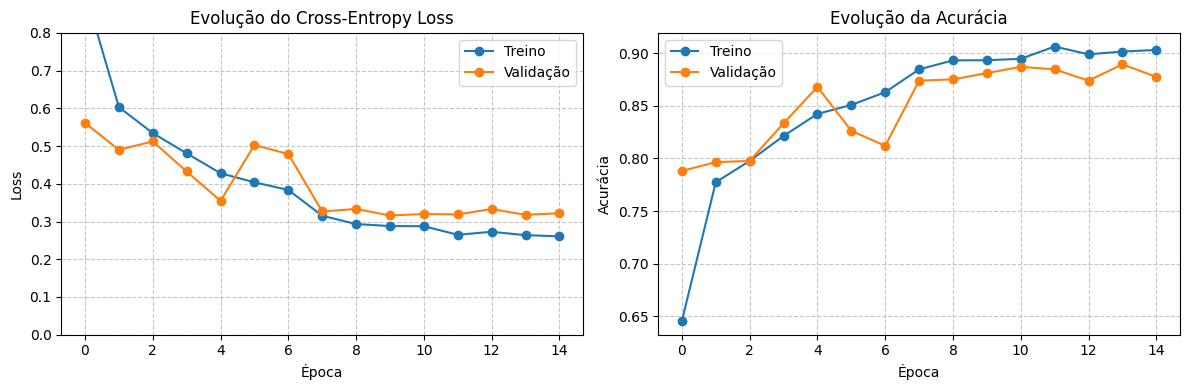

✅ Gráfico salvo com sucesso como 'curvas_treinamento_baseline.png'


In [11]:
model_ft = model_ft.to(device)
criterion = torch.nn.CrossEntropyLoss(weight=class_weights.to(device))

# Observe that all parameters are being optimized
optimizer_ft = torch.optim.SGD(model_ft.parameters(), lr=0.0005, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

# Resume from checkpoint if one exists
start_epoch = 0

torch.cuda.empty_cache()

model_ft, history = train_model(model_ft, criterion, optimizer_ft,
                                exp_lr_scheduler, num_epochs=NUM_EPOCHS)

plot_history(history)

In [12]:
def analise_de_erros_validacao(model, dataloader_valid, class_names):
    # 1. Trava o modelo em modo de avaliação (desliga Dropout, etc)
    model.eval()
    
    todas_preds = []
    todos_labels = []
    imagens_erradas = [] # Vai guardar as imagens para você analisar visualmente
    
    # 2. Desliga o cálculo de gradiente (economiza VRAM)
    with torch.no_grad():
        for inputs, labels in dataloader_valid:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            todas_preds.extend(preds.cpu().numpy())
            todos_labels.extend(labels.cpu().numpy())
            
            # 3. O pulo do gato: Capturar as imagens que ele errou!
            for i in range(len(preds)):
                if preds[i] != labels[i]:
                    imagens_erradas.append({
                        'imagem': inputs[i].cpu(), # Tensor da imagem
                        'predito': class_names[preds[i]],
                        'real': class_names[labels[i]]
                    })

    # 4. Gera e plota a Matriz de Confusão
    cm = confusion_matrix(todos_labels, todas_preds)
    plt.figure(figsize=(10,8))
    sn.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predictions')
    plt.ylabel('Labels')
    plt.title('Confusion Matrix - Validation')
    plt.show()
    
    return imagens_erradas

def _tensor_para_imagem_numpy(img_tensor):
    img_numpy = img_tensor.numpy().transpose((1, 2, 0))
    mean = np.array([0.507, 0.507, 0.507])
    std = np.array([0.267, 0.267, 0.267])
    img_numpy = std * img_numpy + mean
    img_numpy = np.clip(img_numpy, 0, 1)
    return img_numpy


def _monta_mosaico(imgs_numpy, grid_rows=None, grid_cols=None):
    n = len(imgs_numpy)
    if n == 0:
        return None

    if grid_rows is None and grid_cols is None:
        grid_cols = int(np.ceil(np.sqrt(n)))
        grid_rows = int(np.ceil(n / grid_cols))
    else:
        if grid_rows is None:
            grid_rows = int(np.ceil(n / grid_cols))
        if grid_cols is None:
            grid_cols = int(np.ceil(n / grid_rows))

    max_slots = grid_rows * grid_cols
    imgs_numpy = imgs_numpy[:max_slots]

    h, w, c = imgs_numpy[0].shape
    pad = np.ones((h, w, c), dtype=imgs_numpy[0].dtype)

    rows = []
    for r in range(grid_rows):
        row_imgs = []
        for c_idx in range(grid_cols):
            idx = r * grid_cols + c_idx
            if idx < len(imgs_numpy):
                row_imgs.append(imgs_numpy[idx])
            else:
                row_imgs.append(pad)
        rows.append(np.concatenate(row_imgs, axis=1))

    return np.concatenate(rows, axis=0)


def visualizar_erros(imagens_erradas, class_names, grid_rows=None, grid_cols=None, include_correct=False):
    class_to_idx = {name: i for i, name in enumerate(class_names)}
    n_classes = len(class_names)

    cells = [[[] for _ in range(n_classes)] for _ in range(n_classes)]
    for erro in imagens_erradas:
        real = erro.get('real')
        pred = erro.get('predito')
        if real not in class_to_idx or pred not in class_to_idx:
            continue
        if (not include_correct) and real == pred:
            continue
        cells[class_to_idx[real]][class_to_idx[pred]].append(erro['imagem'])

    figsize_per_cell = 2.4
    fig, axes = plt.subplots(
        n_classes,
        n_classes,
        figsize=(figsize_per_cell * n_classes, figsize_per_cell * n_classes)
    )

    if n_classes == 1:
        axes = np.array([[axes]])

    for i, real in enumerate(class_names):
        for j, pred in enumerate(class_names):
            ax = axes[i, j]
            imgs_numpy = [_tensor_para_imagem_numpy(img) for img in cells[i][j]]
            mosaic = _monta_mosaico(imgs_numpy, grid_rows=grid_rows, grid_cols=grid_cols)

            if mosaic is not None:
                ax.imshow(mosaic)
            else:
                ax.set_facecolor('whitesmoke')

            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_frame_on(True)

            if i == 0:
                ax.set_title(f"Pred: {pred}")
            if j == 0:
                ax.set_ylabel(f"Real: {real}")

    plt.tight_layout()
    plt.show()



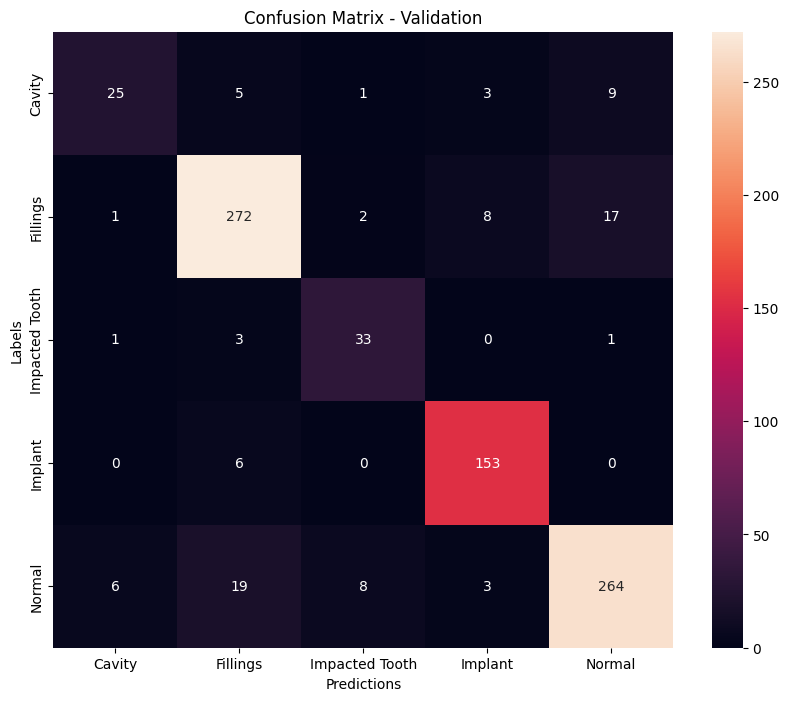

In [13]:
wrong_images = analise_de_erros_validacao(model_ft, dataloaders['valid'], class_names)
# visualizar_erros(wrong_images, class_names, 3, 5)

In [14]:
# Evaluate on the held-out test set using the SAME eval-mode, no-grad path as
# validation. _predict() already calls model.eval() and is wrapped in
# @torch.no_grad(), so Dropout is disabled and predictions are deterministic.
y_true, y_pred = _predict(model_ft, dataloaders['test'])

Test Accuracy: 0.8905013192612137
Test F1 Score (macro): 0.7938270068010327
Test F1 Score (weighted): 0.891160023104918


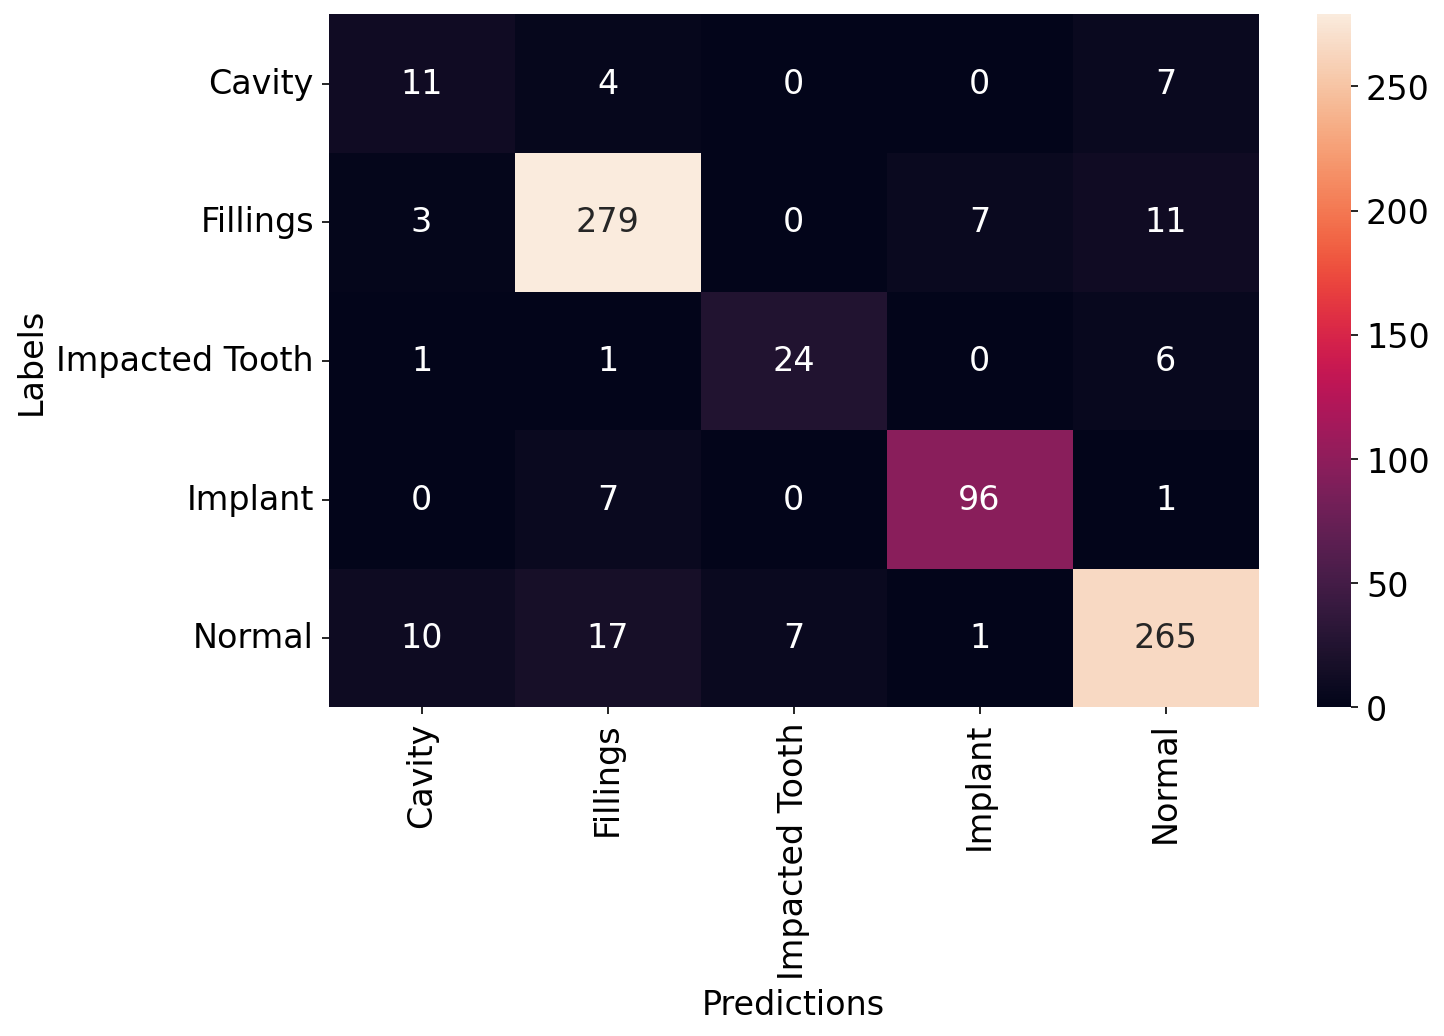

In [15]:
test_accuracy = 0
for iter1 in range(len(y_true)):
    if y_true[iter1] == y_pred[iter1]:
        test_accuracy = test_accuracy + 1

print('Test Accuracy:', test_accuracy / len(y_true))

# F1 scores computed only on test predictions
test_f1_macro = f1_score(y_true, y_pred, average='macro')
test_f1_weighted = f1_score(y_true, y_pred, average='weighted')
print('Test F1 Score (macro):', test_f1_macro)
print('Test F1 Score (weighted):', test_f1_weighted)

classes = ('Cavity','Fillings','Impacted Tooth','Implant','Normal')

# Build confusion matrix
cf_matrix = confusion_matrix(y_true, y_pred)
df_cm = pd.DataFrame(cf_matrix, index = [i for i in classes],
                     columns = [i for i in classes])



plt.figure(figsize = (10,6),dpi=150)
plt.rcParams['font.size'] = '16'
fig = sn.heatmap(df_cm, annot=True, fmt=".0f")
plt.ylabel("Labels")
plt.xlabel("Predictions")
plt.show(fig)

fig.figure.savefig('Confusion_test.pdf', bbox_inches = 'tight')

In [16]:
# Log this run to the master CSV. Runs at the END so it reuses the SINGLE test
# pass from the test cell above (y_true / y_pred = test predictions) — no extra
# forward pass. Validation metrics are still computed inside log_experiment.
log_experiment(
    run_name=RUN_NAME,
    history=history,
    model=model_ft,
    valid_loader=dataloaders["valid"],
    test_y_true=y_true,          # test predictions from the cell above
    test_y_pred=y_pred,
    class_names=class_names,
    seed=ACTIVE_RUN_SEED,
    num_epochs=NUM_EPOCHS,
    aug_desc="rotation10+perspective+hflip+vflip+autocontrast+jitter+blur",  # describe the transforms
    notes=f"class_weight_mode={CLASS_WEIGHT_MODE}, weights={[round(float(w), 3) for w in class_weights]}",
)



===== weighted-ce-manual (seed 42) =====
best val acc   : 0.8893 @ epoch 13
gap acc / loss : 0.0122 / 0.0539   (smaller = curves closer)
val  macro-F1  : 0.8388
test acc       : 0.8905
test macro-F1  : 0.7938
   recall Cavity           0.581
   recall Fillings         0.907
   recall Impacted Tooth   0.868
   recall Implant          0.962
   recall Normal           0.880
saved -> new-results/15-epoch\weighted-ce-manual\seed42


{'run_name': 'weighted-ce-manual',
 'seed': 42,
 'epoch_tag': '15-epoch',
 'num_epochs': 15,
 'best_val_epoch': 13,
 'best_val_acc': 0.8892857142857142,
 'gap_acc_best': 0.012158009933496139,
 'gap_loss_best': 0.05390125918617816,
 'final_gap_acc': 0.02553595981704404,
 'final_gap_loss': 0.06113510091708596,
 'val_macro_f1': 0.838799532263699,
 'val_weighted_f1': 0.8879673916608399,
 'recall_Cavity': 0.5813953488372093,
 'recall_Fillings': 0.9066666666666666,
 'recall_Impacted_Tooth': 0.868421052631579,
 'recall_Implant': 0.9622641509433962,
 'recall_Normal': 0.88,
 'test_acc': 0.8905013192612137,
 'test_macro_f1': 0.7938270068010327,
 'test_weighted_f1': 0.891160023104918,
 'test_recall_Cavity': 0.5,
 'test_recall_Fillings': 0.93,
 'test_recall_Impacted_Tooth': 0.75,
 'test_recall_Implant': 0.9230769230769231,
 'test_recall_Normal': 0.8833333333333333,
 'aug_desc': 'rotation10+perspective+hflip+vflip+autocontrast+jitter+blur',
 'notes': 'class_weight_mode=manual, weights=[1.667, 1.0, 